In [3]:
import os
import urllib.request

# 1. Bikin folder 'images' otomatis kalau belum ada
if not os.path.exists('images'):
    os.makedirs('images')

# 2. Link gambar sampel standar yang sering dipakai buat pengolahan citra (Gambar Lena)
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
path_simpan = "images/citra_yang_digunakan.jpg"

# 3. Download dan simpan ke folder tujuan
urllib.request.urlretrieve(url, path_simpan)

print("Beres! Gambar berhasil didownload dan disimpan otomatis di:", path_simpan)

Beres! Gambar berhasil didownload dan disimpan otomatis di: images/citra_yang_digunakan.jpg


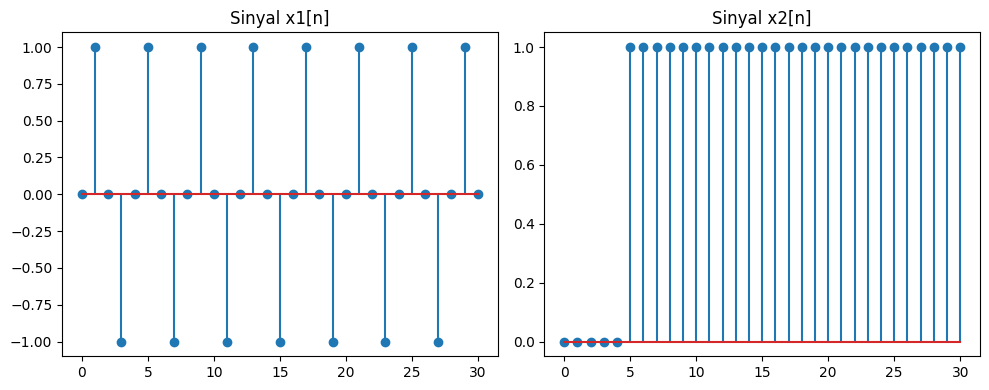

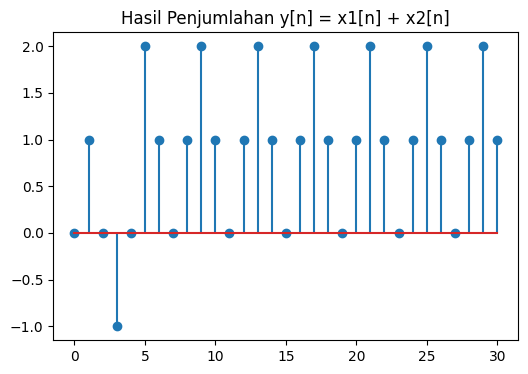

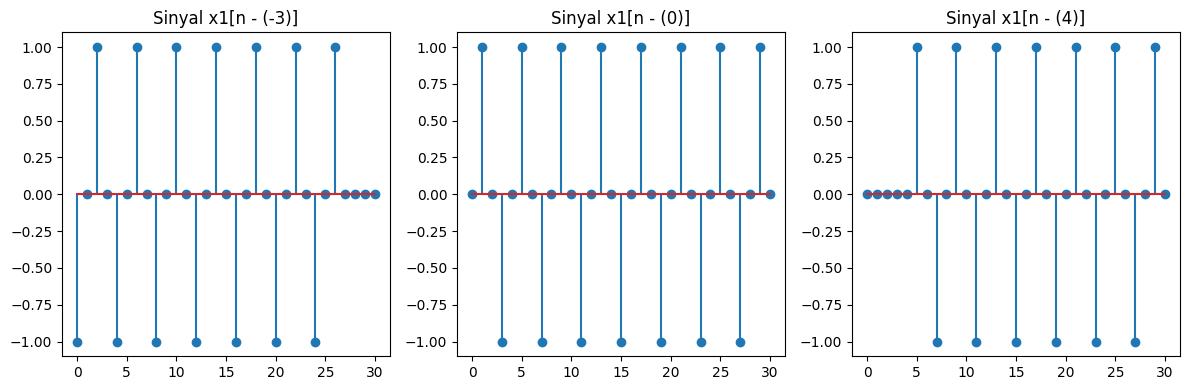

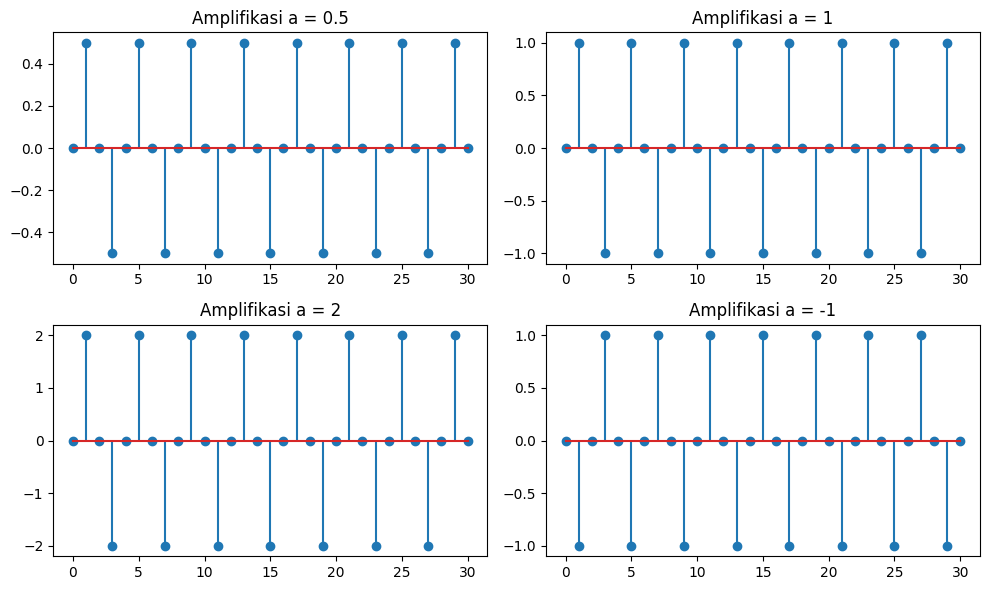

--- B.1 Membaca Citra ---
Ukuran citra: (512, 512)
Tipe Data: uint8
Nilai Minimum Piksel: 18
Nilai Maksimum Piksel: 248


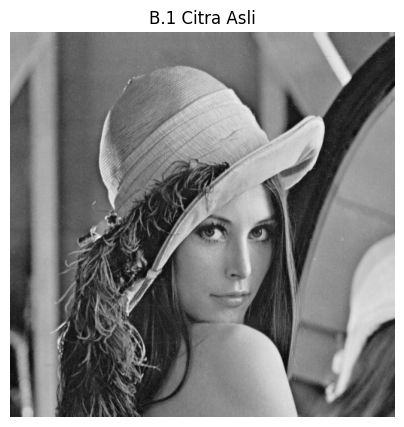


--- B.2 Operasi Penjumlahan Citra ---


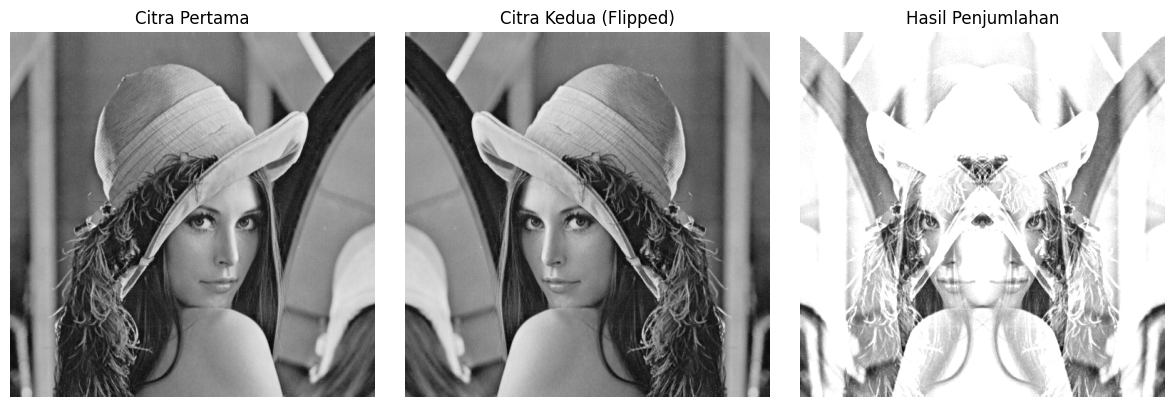


--- B.3 Operasi Penggeseran Citra ---


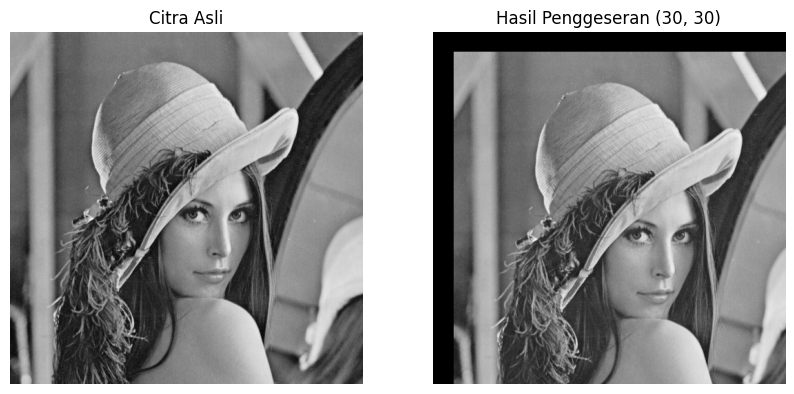


--- B.4 Operasi Amplifikasi Citra ---


/tmp/ipykernel_770/400625296.py:125: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_amp.ravel(), 256, [0,256])


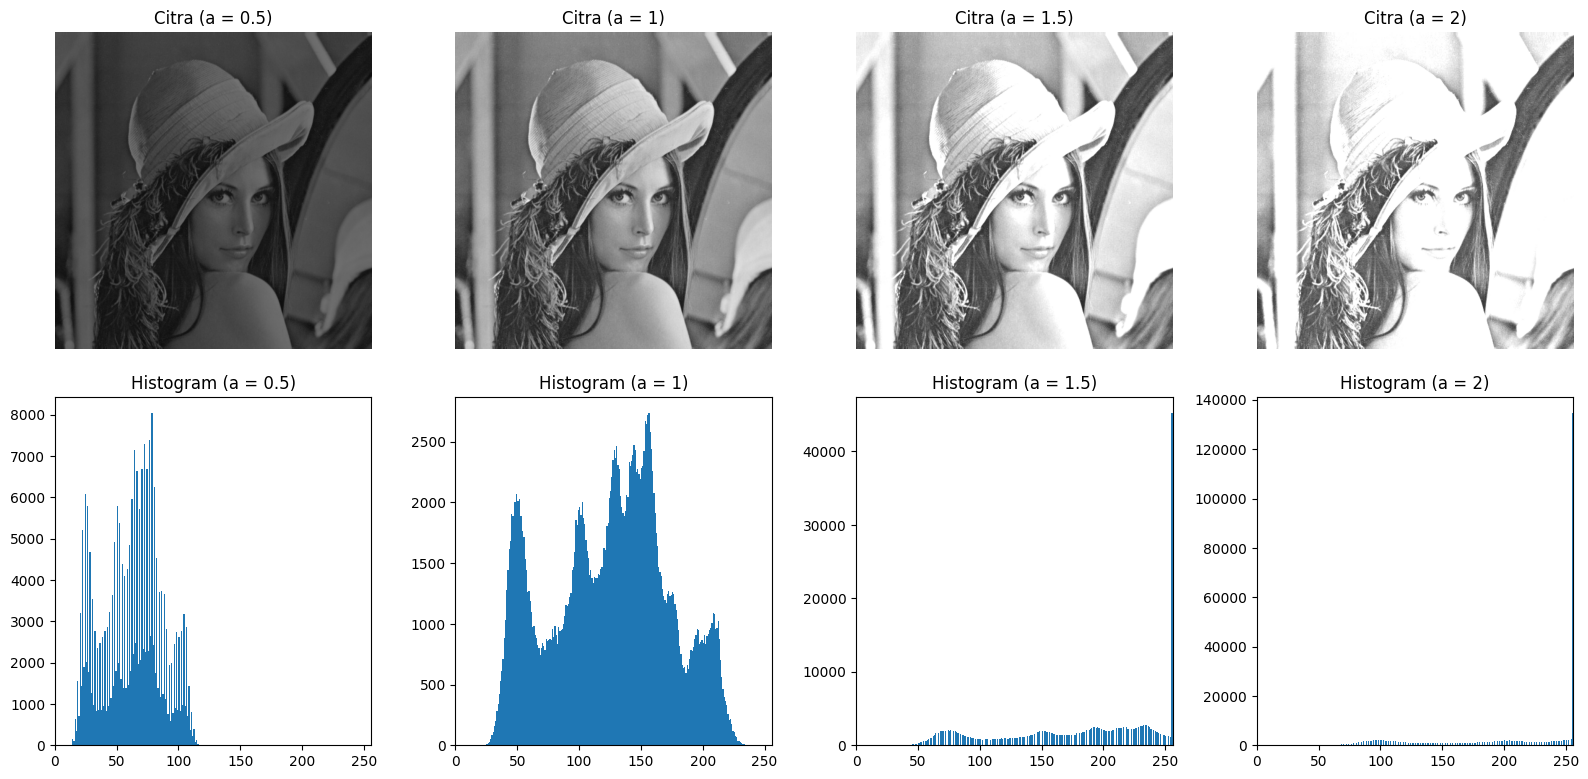

Sistem T(x)=2x memenuhi homogenitas: True


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # atau PIL

# ==========================================
# 1. BAGIAN A: Operasi Sinyal 1D
# ==========================================
n = np.arange(0, 31)

# A.1 Membuat Sinyal Diskrit
x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n < 5, 0, 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.stem(n, x1); plt.title("Sinyal x1[n]")
plt.subplot(1,2,2); plt.stem(n, x2); plt.title("Sinyal x2[n]")
plt.tight_layout(); plt.show()

# A.2 Operasi Penjumlahan Sinyal
y_add = x1 + x2
plt.figure(figsize=(6,4))
plt.stem(n, y_add)
plt.title("Hasil Penjumlahan y[n] = x1[n] + x2[n]")
plt.show()

# A.3 Operasi Penggeseran Sinyal
def shift_signal(x, k):
    y = np.zeros_like(x)
    if k > 0:
        y[k:] = x[:-k]
    elif k < 0:
        y[:k] = x[-k:]
    else:
        y = x.copy()
    return y

k_values = [-3, 0, 4]
plt.figure(figsize=(12, 4))
for i, k in enumerate(k_values):
    plt.subplot(1, 3, i+1)
    plt.stem(n, shift_signal(x1, k))
    plt.title(f"Sinyal x1[n - ({k})]")
plt.tight_layout(); plt.show()

# A.4 Operasi Amplifikasi Sinyal
alphas = [0.5, 1, 2, -1]
plt.figure(figsize=(10, 6))
for i, a in enumerate(alphas):
    plt.subplot(2, 2, i+1)
    plt.stem(n, a * x1)
    plt.title(f"Amplifikasi a = {a}")
plt.tight_layout(); plt.show()

# ==========================================
# 2. BAGIAN B: Operasi pada Citra 2D
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# B.1 Membaca dan Menampilkan Citra
# Pastikan path file gambar sesuai dengan struktur folder kamu
img1 = cv2.imread('images/citra_yang_digunakan.jpg', cv2.IMREAD_GRAYSCALE)

if img1 is not None:
    print("--- B.1 Membaca Citra ---")
    print(f"Ukuran citra: {img1.shape}")
    print(f"Tipe Data: {img1.dtype}")
    print(f"Nilai Minimum Piksel: {img1.min()}")
    print(f"Nilai Maksimum Piksel: {img1.max()}")

    plt.figure(figsize=(5,5))
    plt.imshow(img1, cmap='gray')
    plt.title("B.1 Citra Asli")
    plt.axis('off')
    plt.show()

    # ==========================================
    # B.2 Operasi Penjumlahan Citra
    print("\n--- B.2 Operasi Penjumlahan Citra ---")
    # Membuat citra kedua dengan ukuran yang sama (menggunakan gambar yang di-flip)
    img2 = cv2.flip(img1, 1)

    # Menjumlahkan citra (cv2.add otomatis melakukan clipping di batas 255)
    img_add = cv2.add(img1, img2)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img1, cmap='gray'); plt.title("Citra Pertama"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(img2, cmap='gray'); plt.title("Citra Kedua (Flipped)"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(img_add, cmap='gray'); plt.title("Hasil Penjumlahan"); plt.axis('off')
    plt.tight_layout(); plt.show()

    # ==========================================
    # B.3 Operasi Penggeseran Citra
    print("\n--- B.3 Operasi Penggeseran Citra ---")
    rows, cols = img1.shape

    # Matriks translasi (Delta i=30 ke kanan, Delta j=30 ke bawah)
    M = np.float32([[1, 0, 30], [0, 1, 30]])
    img_shift = cv2.warpAffine(img1, M, (cols, rows))

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.imshow(img1, cmap='gray'); plt.title("Citra Asli"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img_shift, cmap='gray'); plt.title("Hasil Penggeseran (30, 30)"); plt.axis('off')
    plt.show()

    # ==========================================
    # B.4 Operasi Amplifikasi Citra
    print("\n--- B.4 Operasi Amplifikasi Citra ---")
    alphas_img = [0.5, 1, 1.5, 2]
    plt.figure(figsize=(16, 8))

    for i, a in enumerate(alphas_img):
        # cv2.convertScaleAbs digunakan untuk mencegah overflow nilai (clipping otomatis ke 0-255)
        img_amp = cv2.convertScaleAbs(img1, alpha=a, beta=0)

        # Plot Gambar Hasil Amplifikasi
        plt.subplot(2, 4, i+1)
        plt.imshow(img_amp, cmap='gray', vmin=0, vmax=255)
        plt.title(f"Citra (a = {a})")
        plt.axis('off')

        # Plot Histogram
        plt.subplot(2, 4, i+5)
        plt.hist(img_amp.ravel(), 256, [0,256])
        plt.title(f"Histogram (a = {a})")
        plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()

else:
    print("Error: Gambar tidak ditemukan! Pastikan path file ('images/citra_yang_digunakan.jpg') sudah benar.")

# ==========================================
# 3. BAGIAN C: Uji Sistem Linier
# ==========================================
# C.1 Uji Homogenitas (T(x) = 2x)
alpha = 2

T_x = 2 * x1
T_ax = 2 * (alpha * x1)
a_Tx = alpha * (2 * x1)

# Pengecekan kesamaan array
is_homogen = np.allclose(T_ax, a_Tx)
print(f"Sistem T(x)=2x memenuhi homogenitas: {is_homogen}")